# Unidad 7 · Machine learning aplicado a criptoactivos

**Qué vas a aprender**
- Qué es el aprendizaje **supervisado** y la diferencia entre **clasificación** y **regresión**.
- Preparar variables y objetivo, y dividir en entrenamiento y prueba **sin mirar el futuro**.
- Entrenar regresión logística, **árboles de decisión** y **random forest**, y evaluarlos contra una
  línea base.
- Interpretar un modelo: importancia de variables, y por qué una importancia alta no significa que el
  modelo sirva.

**Qué tiene que ver con la app.** El piloto **no usa machine learning para adivinar la dirección**. Al
final de este cuaderno tendrás la prueba de por qué: el mejor modelo no le gana a una moneda al aire.
Pero el mismo modelo, apuntando a la **volatilidad**, funciona. Y ahí el piloto usa algo mucho más
simple, la EWMA, que se queda muy cerca del random forest.

In [1]:
#@title Preparación: ejecuta esta celda primero (▶). Carga los precios de Binance.
# Es la misma en todos los cuadernos. Cómo se construye se explica en la Unidad 1.
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})

ACTIVOS = ["BTC", "ETH", "SOL"]        # las monedas de la cartera de ejemplo del piloto
COLORES = {"BTC": "#F7931A", "ETH": "#627EEA", "SOL": "#9945FF"}
DESDE = "2020-01-01"                    # el piloto también mira desde 2020
HASTA = "2026-09-26"                    # fija las cifras del texto; None = hasta ayer
ANUAL = 365                             # las criptos cotizan todos los días del año
API = "https://data-api.binance.vision/api/v3/klines"   # api.binance.com bloquea Colab


def descargar(simbolo, desde=DESDE):
    """Velas diarias YA CERRADAS de SIMBOLO/USDT en Binance, 1000 por petición."""
    inicio = int(pd.Timestamp(desde, tz="UTC").timestamp() * 1000)
    filas = []
    while True:
        r = requests.get(API, params={"symbol": f"{simbolo}USDT", "interval": "1d",
                                      "startTime": inicio, "limit": 1000}, timeout=30)
        r.raise_for_status()
        lote = r.json()
        filas += lote
        if len(lote) < 1000:
            break
        inicio = lote[-1][0] + 1                      # la página siguiente empieza tras la última vela
    crudo = pd.DataFrame([f[:7] for f in filas],
                         columns=["apertura_ms", "open", "high", "low", "close", "volume", "cierre_ms"])
    crudo = crudo[crudo["cierre_ms"] < pd.Timestamp.now(tz="UTC").timestamp() * 1000]
    df = pd.DataFrame({"fecha": pd.to_datetime(crudo["apertura_ms"], unit="ms", utc=True)})
    for c in ["open", "high", "low", "close", "volume"]:
        df[c] = crudo[c].astype(float).to_numpy()
    return df.drop_duplicates("fecha").reset_index(drop=True)


def velas(simbolo):
    """Velas diarias del periodo de estudio: del CSV si ya está, si no de Binance (y lo guarda)."""
    archivo = f"{simbolo}USDT_1d.csv"
    hoy = pd.Timestamp.now(tz="UTC").normalize()
    fin = pd.Timestamp(HASTA, tz="UTC") if HASTA else hoy - pd.Timedelta(days=1)
    df = None
    if os.path.exists(archivo):
        df = pd.read_csv(archivo)
        df["fecha"] = pd.to_datetime(df["fecha"], utc=True)
    if df is None or df["fecha"].max() < fin:
        try:
            df = descargar(simbolo)
            df.to_csv(archivo, index=False, date_format="%Y-%m-%dT%H:%M:%SZ")
        except requests.RequestException as e:
            if df is None:
                raise RuntimeError(f"No pude descargar {simbolo} de Binance ({e}). Sube {archivo} "
                                   "(carpeta de datos de respaldo del curso) y repite.") from None
            print(f"Aviso: sin conexión con Binance; {archivo} llega solo al {df['fecha'].max():%d-%m-%Y}.")
    df = df[(df["fecha"] >= pd.Timestamp(DESDE, tz="UTC")) & (df["fecha"] <= fin)]
    return df.set_index("fecha")


def cierres(activos=ACTIVOS):
    """Cierres diarios, una columna por moneda: la tabla con la que trabaja el piloto."""
    return pd.DataFrame({a: velas(a)["close"] for a in activos})


print(f"Listo. Periodo de estudio: del {DESDE} al {HASTA or 'día de ayer'}.")

Listo. Periodo de estudio: del 2020-01-01 al 2026-09-26.


In [2]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, r2_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text

SEMILLA = 42                                      # para que el azar del random forest se repita igual

## 1. Qué es el aprendizaje supervisado

Se le dan al modelo muchos ejemplos de **variables** (X) con su **respuesta** (y), y aprende una regla
que va de X a y. Luego se le dan X nuevas y predice y.

| Tipo | La respuesta es… | Ejemplo aquí |
|---|---|---|
| **clasificación** | una categoría | ¿mañana BTC sube o baja? |
| **regresión** | un número | ¿cuánto sube mañana? ¿cuánto se moverá esta semana? |

Tres trampas que en finanzas son la norma, no la excepción:
1. **Fuga de información**: una variable o una división que usa el futuro (Unidad 3).
2. **Sobreajuste**: el modelo memoriza el ruido del pasado y falla con datos nuevos.
3. **Cambio de régimen**: lo que funcionó en 2021 puede no valer en 2025.

## 2. Preparación: variables y objetivos

Las variables de la Unidad 3, todas calculadas con datos hasta el cierre del día t:

In [3]:
btc = velas("BTC")
d = pd.DataFrame({"close": btc["close"], "volume": btc["volume"]})
d["r"] = np.log(d["close"]).diff()
for k in range(1, 5):
    d[f"r_{k}"] = d["r"].shift(k)                                   # rendimientos de los 4 días anteriores
d["vol_7"] = d["r"].rolling(7).std() * np.sqrt(ANUAL)
d["vol_30"] = d["r"].rolling(30).std() * np.sqrt(ANUAL)
d["vol_ewma"] = np.sqrt((d["r"] ** 2).ewm(alpha=0.06, adjust=False).mean() * ANUAL)
d["dist_sma50"] = d["close"] / d["close"].rolling(50).mean() - 1
d["mom_30"] = np.log(d["close"]).diff(30)
cambio = d["close"].diff()
d["rsi_14"] = 100 - 100 / (1 + cambio.clip(lower=0).ewm(alpha=1 / 14, adjust=False).mean()
                           / (-cambio.clip(upper=0)).ewm(alpha=1 / 14, adjust=False).mean())
d["vol_rel"] = d["volume"] / d["volume"].rolling(30).mean()
VARIABLES = ["r", "r_1", "r_2", "r_3", "r_4", "vol_7", "vol_30", "vol_ewma", "dist_sma50", "mom_30", "rsi_14", "vol_rel"]

# Objetivos: lo único que mira al futuro, a propósito.
d["r_manana"] = d["r"].shift(-1)
d["sube"] = (d["r_manana"] > 0).astype(int)
d["vol_futura"] = d["r"].rolling(7).std().shift(-7) * np.sqrt(ANUAL)   # volatilidad de t+1 a t+7
datos = d[VARIABLES + ["r_manana", "sube", "vol_futura"]].dropna()
print(len(datos), "días con todas las variables y objetivos;", f"BTC subió el {datos['sube'].mean():.1%} de ellos")

2405 días con todas las variables y objetivos; BTC subió el 50.8% de ellos


## 3. División en entrenamiento y prueba

Entrenamiento: hasta 2023. Prueba: de 2024 al 26-09-2026, unos 1000 días que el modelo nunca vio.
Siempre **por fecha**, nunca al azar.

¿Por qué tanto empeño? Mira lo que pasa con un objetivo a 30 días: *¿estará BTC más alto dentro de 30
días?* Dos días seguidos comparten 29 de esos 30 días, así que su respuesta casi siempre coincide. Si
se divide al azar, cada día de la prueba tiene a sus vecinos en el entrenamiento, y el modelo solo
tiene que copiarlos.

In [4]:
corte = "2024-01-01"
entreno, prueba = datos[datos.index < corte], datos[datos.index >= corte]
print(f"Entrenamiento: {len(entreno)} días ({entreno.index[0]:%d-%m-%Y} a {entreno.index[-1]:%d-%m-%Y})")
print(f"Prueba:        {len(prueba)} días ({prueba.index[0]:%d-%m-%Y} a {prueba.index[-1]:%d-%m-%Y})")

futuro = d["close"].shift(-30)
d["sube_30"] = (futuro > d["close"]).astype(float).where(futuro.notna())
x30 = d[VARIABLES + ["sube_30"]].dropna()
bosque = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, max_features="sqrt", random_state=SEMILLA, n_jobs=-1)
azar = x30.sample(frac=1, random_state=SEMILLA)                     # días barajados
n = int(len(azar) * 0.7)
acierto_azar = accuracy_score(azar["sube_30"].iloc[n:],
                              bosque.fit(azar[VARIABLES].iloc[:n], azar["sube_30"].iloc[:n]).predict(azar[VARIABLES].iloc[n:]))
e30, p30 = x30[x30.index < corte], x30[x30.index >= corte]
acierto_fecha = accuracy_score(p30["sube_30"], bosque.fit(e30[VARIABLES], e30["sube_30"]).predict(p30[VARIABLES]))
print(f"\n¿Más alto en 30 días? Acierto con división al azar: {acierto_azar:.1%} | por fecha: {acierto_fecha:.1%}"
      f" | decir siempre «sube» en la prueba: {(p30['sube_30'] == 1).mean():.1%}")

Entrenamiento: 1412 días (19-02-2020 a 31-12-2023)
Prueba:        993 días (01-01-2024 a 19-09-2026)



¿Más alto en 30 días? Acierto con división al azar: 62.7% | por fecha: 49.3% | decir siempre «sube» en la prueba: 55.8%


Dividido al azar, el modelo parece acertar casi dos de cada tres veces: un "bot" listo para vender.
Dividido por fecha, acierta menos que decir siempre "sube". En la realidad solo tendrás el pasado para
entrenar, y la división por fecha es la que mide eso.

## 4. Clasificación: ¿mañana sube o baja?

Antes de cualquier modelo, las **líneas base**: estrategias tontas que un modelo tiene que superar.
- **Siempre lo más frecuente** en el entrenamiento ("siempre sube", si subió más días).
- **Repite hoy**: si hoy subió, mañana sube.

Y tres modelos, de más simple a más flexible:
- **Regresión logística**: una combinación lineal de las variables convertida en probabilidad.
- **Árbol de decisión** de 3 niveles: preguntas sí/no sobre las variables.
- **Random forest**: 300 árboles, cada uno con una muestra distinta de días y de variables; vota la mayoría.

Además del **acierto** (porcentaje de días bien clasificados), el **AUC**: la probabilidad de que el
modelo dé más probabilidad de subir a un día que subió que a uno que bajó. 0,5 = azar.

In [5]:
Xe, ye, Xp, yp = entreno[VARIABLES], entreno["sube"], prueba[VARIABLES], prueba["sube"]
escala = StandardScaler().fit(Xe)                    # la logística prefiere variables en la misma escala

clasificadores = {
    "regresión logística": LogisticRegression(C=1e9, max_iter=5000),
    "árbol (3 niveles)": DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, random_state=SEMILLA),
    "random forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=20, max_features="sqrt",
                                            random_state=SEMILLA, n_jobs=-1),
}
mayoria = int(ye.mean() > 0.5)
filas = {"siempre «" + ("sube" if mayoria else "baja") + "»": {"acierto": (yp == mayoria).mean(), "AUC": 0.5},
         "repite hoy": {"acierto": ((prueba["r"] > 0).astype(int) == yp).mean(), "AUC": np.nan}}
for nombre, m in clasificadores.items():
    xe, xp = (escala.transform(Xe), escala.transform(Xp)) if "logística" in nombre else (Xe, Xp)
    m.fit(xe, ye)
    prob = m.predict_proba(xp)[:, 1]
    filas[nombre] = {"acierto": accuracy_score(yp, prob > 0.5), "AUC": roc_auc_score(yp, prob)}
pd.DataFrame(filas).T.round(3)

,acierto,AUC
siempre «sube»,0.507,0.500
repite hoy,0.489,NaN
regresión logística,0.512,0.525
árbol (3 niveles),0.493,0.498
random forest,0.490,0.492


Ningún modelo se separa de las líneas base: aciertos alrededor del 50 % y AUC alrededor de 0,5. Con
unos 1000 días de prueba, el margen de error del acierto es de ±3 puntos: diferencias menores son ruido.

Así decide el árbol. Las reglas parecen sensatas ("si el RSI está alto y la volatilidad baja..."), pero
fuera de la muestra no aciertan más que el azar:

In [6]:
print(export_text(clasificadores["árbol (3 niveles)"], feature_names=VARIABLES, decimals=3))

|--- r <= -0.024
|   |--- r_2 <= 0.028
|   |   |--- r_4 <= -0.031
|   |   |   |--- class: 1
|   |   |--- r_4 >  -0.031
|   |   |   |--- class: 1
|   |--- r_2 >  0.028
|   |   |--- class: 0
|--- r >  -0.024
|   |--- vol_30 <= 0.341
|   |   |--- vol_30 <= 0.325
|   |   |   |--- class: 1
|   |   |--- vol_30 >  0.325
|   |   |   |--- class: 1
|   |--- vol_30 >  0.341
|   |   |--- r_3 <= 0.073
|   |   |   |--- class: 0
|   |   |--- r_3 >  0.073
|   |   |   |--- class: 0



In [7]:
rf = clasificadores["random forest"]
matriz = pd.DataFrame(confusion_matrix(yp, rf.predict(Xp)), index=["bajó", "subió"], columns=["predijo baja", "predijo sube"])
print("Matriz de confusión del random forest en la prueba:")
matriz

Matriz de confusión del random forest en la prueba:


,predijo baja,predijo sube
bajó,217,273
subió,233,270


## 5. Regresión: ¿cuánto se moverá?

Las mismas variables, dos objetivos numéricos. Se compara con predecir siempre la media del
entrenamiento (R² = 0) y, para la volatilidad, con la regla de una línea del piloto: **la volatilidad
de la semana que viene será la EWMA de hoy**.

In [8]:
def r2_fuera(y, pred, referencia):
    return 1 - ((y - pred) ** 2).sum() / ((y - referencia) ** 2).sum()


filas = {}
for objetivo in ["r_manana", "vol_futura"]:
    ye_, yp_ = entreno[objetivo], prueba[objetivo]
    lineal = LinearRegression().fit(Xe, ye_)
    bosque = RandomForestRegressor(n_estimators=300, min_samples_leaf=20, max_features="sqrt",
                                   random_state=SEMILLA, n_jobs=-1).fit(Xe, ye_)
    filas[objetivo] = {"regresión lineal": r2_fuera(yp_, lineal.predict(Xp), ye_.mean()),
                       "random forest": r2_fuera(yp_, bosque.predict(Xp), ye_.mean())}
    if objetivo == "vol_futura":
        filas[objetivo]["EWMA de hoy, sin modelo"] = r2_fuera(yp_, prueba["vol_ewma"], ye_.mean())
        bosque_vol = bosque
pd.DataFrame(filas).T.round(3)

,regresión lineal,random forest,"EWMA de hoy, sin modelo"
r_manana,0.000,-0.018,NaN
vol_futura,0.409,0.352,0.358


- **Rendimiento de mañana**: R² negativo o cero. Ningún modelo predice cuánto subirá BTC mejor que la media.
- **Volatilidad de la semana próxima**: R² claramente positivo, alrededor de 0,35-0,4. La EWMA de hoy,
  sin entrenar nada, queda a la par del random forest con 12 variables, y la regresión lineal los
  supera a los dos: con poca señal, el modelo flexible no aporta.

## 6. Interpretar: qué variables usa el modelo

Dos formas de medir la importancia de cada variable:
- **Por impureza**: cuánto ayuda la variable a separar los datos **de entrenamiento** en los árboles.
  Siempre reparte importancia, aunque el modelo no sirva.
- **Por permutación**: cuánto **empeora el modelo en la prueba** si se barajan los valores de esa
  variable. Si barajarla no cambia nada, el modelo no la usaba para algo útil.

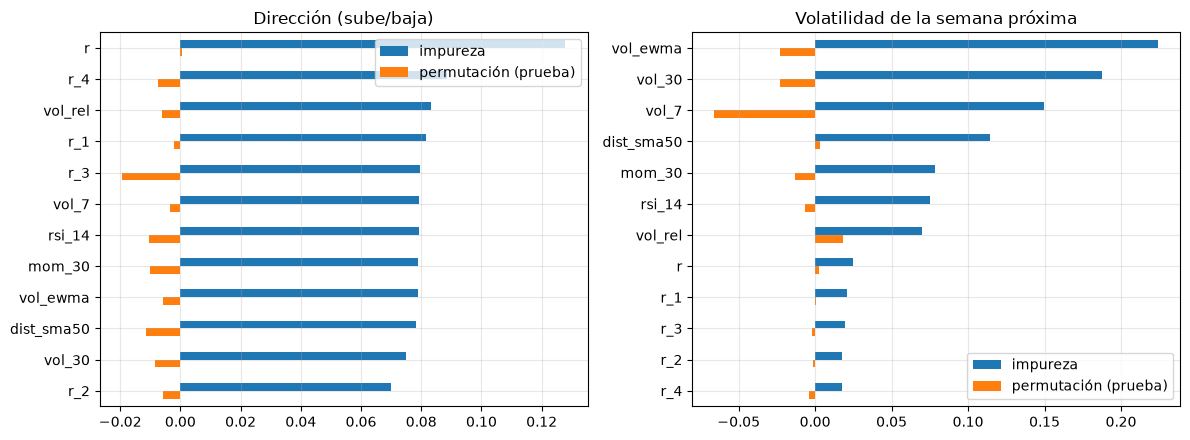

In [9]:
def importancias(modelo, X, y, puntuacion):
    perm = permutation_importance(modelo, X, y, n_repeats=10, random_state=SEMILLA, scoring=puntuacion, n_jobs=-1)
    return pd.DataFrame({"impureza": modelo.feature_importances_, "permutación (prueba)": perm.importances_mean},
                        index=X.columns).sort_values("impureza", ascending=False)


imp_dir = importancias(rf, Xp, yp, "accuracy")
imp_vol = importancias(bosque_vol, Xp, prueba["vol_futura"], "r2")
fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))
imp_dir.plot.barh(ax=ejes[0], title="Dirección (sube/baja)").invert_yaxis()
imp_vol.plot.barh(ax=ejes[1], title="Volatilidad de la semana próxima").invert_yaxis()
plt.tight_layout(); plt.show()

En el modelo de **dirección**, la importancia por impureza se reparte entre todas las variables, pero la
de permutación es casi cero o negativa en todas: el modelo encontró patrones en el entrenamiento que no
se repiten. En el de **volatilidad**, las dos medidas coinciden en que lo que importa es la volatilidad
reciente (`vol_ewma`, `vol_7`, `vol_30`).

**Una importancia alta no significa que el modelo sirva.** Primero se comprueba que el modelo le gana a
la línea base fuera de la muestra; solo entonces tiene sentido preguntar qué variables usa.

## 7. Caso aplicado: un año tras otro

Un resultado en un solo periodo de prueba puede ser suerte. La **validación hacia delante**
(*walk-forward*) repite el ejercicio: para cada año, se entrena con todos los anteriores y se prueba
en ese año.

In [10]:
filas = []
for ano in range(2022, 2027):
    e_, p_ = datos[datos.index.year < ano], datos[datos.index.year == ano]
    m = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, max_features="sqrt",
                               random_state=SEMILLA, n_jobs=-1).fit(e_[VARIABLES], e_["sube"])
    base = int(e_["sube"].mean() > 0.5)
    filas.append({"año": ano, "días": len(p_), "acierto del modelo": accuracy_score(p_["sube"], m.predict(p_[VARIABLES])),
                  "acierto de la línea base": (p_["sube"] == base).mean()})
anos = pd.DataFrame(filas).set_index("año")
total = anos["días"].sum()
anos.loc["todos"] = [total, (anos["acierto del modelo"] * anos["días"]).sum() / total,
                     (anos["acierto de la línea base"] * anos["días"]).sum() / total]
anos["días"] = anos["días"].astype(int)
print(f"Margen de error del acierto con {total} días: ±{1.96 * np.sqrt(0.25 / total):.1%}")
anos.round(3)

Margen de error del acierto con 1723 días: ±2.4%


,días,acierto del modelo,acierto de la línea base
año,,,
2022,365,0.501,0.458
2023,365,0.553,0.504
2024,366,0.505,0.525
2025,365,0.507,0.501
2026,262,0.469,0.489
todos,1723,0.510,0.496


En 2022 y 2023 el modelo queda 4-5 puntos por encima de la línea base; en 2024 y 2026, por debajo. En
conjunto, poco más de un punto, dentro del margen de error. Es lo que se espera del azar. (El cuaderno
de R, con otra implementación del random forest, da +2,6 puntos: si una ventaja existe, es frágil.) Un
vendedor de "bots con IA" te enseñaría solo 2023.

## 8. Así lo usa el piloto

- **No predice la dirección.** La tesis lo contrastó con 8 criptoactivos y un protocolo registrado de
  antemano: ganar más que la pasiva con el mismo riesgo **no se demostró** (hipótesis HE4). Este
  cuaderno llega a lo mismo con BTC: ni logística, ni árbol, ni random forest le ganan al azar.
- **Predice la volatilidad**, que sí se deja: R² positivo fuera de la muestra. Y lo hace con la EWMA
  (Unidad 6), una línea sin entrenar, que se queda cerca del random forest. Entre dos modelos que
  rinden parecido, el simple gana: se entiende, no se sobreajusta y no falla al reentrenar.
- Si algún día quieres probar una idea de dirección, el sistema principal tiene un **filtro de
  evidencia** (`python -m cryptoquant evidencia`) que la contrasta con estas mismas precauciones.

## Ejercicios

1. **Otro umbral.** En vez de "sube o baja", clasifica "mañana se mueve más de un 3 % en cualquier
   dirección". ¿El random forest le gana ahora a la línea base? ¿Por qué tendría sentido?
2. **Más profundidad.** Entrena un árbol sin límite de profundidad (`max_depth=None, min_samples_leaf=1`).
   Compara su acierto en el entrenamiento y en la prueba. Eso es el sobreajuste.
3. **ETH.** Repite la sección 4 con ETH. ¿Cambia la conclusión?
4. **La fuga.** Añade como variable `d["r"].shift(-1)` (el rendimiento de mañana) y entrena el random
   forest. ¿Qué acierto da? Ese número es el que tiene que hacerte sospechar en cualquier modelo.